# 📊 FIAP - Feature Engineering
## Extração de Features de Dados Não Estruturados: Processamento de Texto

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 2 - Encoding, Discretização e Criação de Features
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais de extração de features de dados textuais:
- **TF-IDF Vectorization:** Transformação de texto em features numéricas
- **Count Vectorization:** Contagem de frequência de termos
- **Text Preprocessing:** Limpeza e pré-processamento de texto
- **Classificação de Texto:** Aplicação em tarefas de detecção de spam

---

### 📊 **Dataset Utilizado**
**SMS Spam Collection Dataset** - Mensagens SMS classificadas
- **Fonte:** Dataset público de detecção de spam em SMS
- **Registros:** Coleção de mensagens SMS rotuladas
- **Features:** Conteúdo textual das mensagens + variável target (spam/ham)
- **Objetivo:** Classificação de mensagens como spam ou ham através de features textuais

---

### 🔧 **Principais Técnicas Aplicadas**
1. **Text Preprocessing:**
   - Limpeza e normalização de texto
   - Remoção de caracteres especiais e stop words

2. **TF-IDF Vectorization:**
   - Term Frequency-Inverse Document Frequency
   - Representação vetorial ponderada do texto

3. **Count Vectorization:**
   - Contagem simples de frequência de termos
   - Bag of Words representation

4. **Validação:**
   - Comparação de diferentes estratégias de vetorização
   - Métricas de classificação e análise de performance

---

# 1. Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para o projeto, organizadas por categoria de uso.

In [1]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE PROCESSAMENTO DE TEXTO - SCIKIT-LEARN
# =============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer  # Vetorização de texto
from sklearn.model_selection import train_test_split      # Divisão de dados em treino/teste
from sklearn.linear_model import LogisticRegression       # Modelo de classificação linear
from sklearn.metrics import accuracy_score, confusion_matrix  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

# 2. Carregamento e Exploração do Dataset

## 2.2. Carregamento dos Dados e Análise Inicial

Vamos começar carregando os dados e fazendo uma análise inicial do dataset para entender melhor sua estrutura e características.

### **Principais Características do Dataset:**
- **label:** Classificação da mensagem (ham = legítima, spam = indesejada)
- **message:** Conteúdo textual da mensagem SMS (string de texto livre)

### **Estrutura dos Dados:**
- **Total de registros:** 5.574 mensagens SMS
- **Distribuição de classes:**
  - **Ham (mensagens legítimas):** ~87% do dataset (~4.825 mensagens)
  - **Spam (mensagens indesejadas):** ~13% do dataset (~747 mensagens)
- **Idioma:** Inglês (com variações de gírias e abreviações típicas de SMS)
- **Formato:** Arquivo CSV com duas colunas (label, message)

### **Características das Mensagens:**
- **Ham (Legítimas):**
  - Conversas pessoais entre amigos/família
  - Lembretes e informações úteis
  - Linguagem natural e contextualizada
  - Comprimento variável, geralmente mais longas
  
- **Spam (Indesejadas):**
  - Mensagens promocionais e publicitárias
  - Ofertas de produtos/serviços
  - Solicitações de informações pessoais
  - Linguagem comercial com urgência artificial
  - URLs, números de telefone e códigos promocionais

### **Desafios do Dataset:**
- **Desbalanceamento:** Proporção desigual entre classes (87% ham vs 13% spam)
- **Variabilidade linguística:** Gírias, abreviações e erros de digitação típicos de SMS
- **Contexto cultural:** Expressões e referências específicas da cultura inglesa
- **Spam evolution:** Spammers adaptam constantemente suas estratégias
- **Ambiguidade:** Algumas mensagens podem ser limítrofes entre spam e ham

### **Relevância para Machine Learning:**
- **Classificação binária:** Problema clássico de detecção de spam
- **Processamento de texto:** Ideal para aprender técnicas de NLP
- **Feature engineering:** Demonstra extração de características de dados não estruturados
- **Aplicação prática:** Relevante para sistemas de filtragem em telecomunicações
- **Métrica de sucesso:** Alta precision para evitar falsos positivos (ham classificado como spam)

### **Aplicações Comerciais:**
- **Operadoras de telefonia:** Filtragem automática de SMS spam
- **Aplicativos de mensagens:** Detecção proativa de conteúdo indesejado
- **Marketing digital:** Análise de efetividade de campanhas SMS
- **Segurança digital:** Identificação de tentativas de phishing via SMS
- **Compliance:** Monitoramento de comunicações para regulamentações

### **Fonte do Dataset:**
- **Origem:** Disponível em repositórios públicos de datasets para NLP
- **Licença:** Uso acadêmico e educacional
- **Formato:** CSV (Comma Separated Values)
- **Objetivo:** Benchmark para algoritmos de classificação de texto

## 2.2 Carregamento do Dataset

In [2]:
# Carregar o dataset usando pandas
df = pd.read_csv("datasets/sms_spam_collection.csv", sep=',', header=None, names=['label', 'message'])

# Remover linha de cabeçalho (se existir)
df = df[df['label'] != 'label']

# Mostrando as primeiras linhas do dataset
df.head()

,label,message
1,ham,"Go until jurong point, crazy.. Available only ..."
2,ham,Ok lar... Joking wif u oni...
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...
4,ham,U dun say so early hor... U c already then say...
5,ham,"Nah I don't think he goes to usf, he lives aro..."


# 3. Análise Exploratória

In [3]:
# Visualizando informações gerais sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5572 entries, 1 to 5572
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 130.6+ KB


In [4]:
# Visualizando estatísticas descritivas
df.describe(include='all')

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


# 4. Pré-processamento do Texto

Nesta etapa, realizaremos o pré-processamento do texto, como remoção de pontuações, conversão para minúsculas, etc.

In [5]:
df_clean = df
df_clean['message_clean'] = df_clean['message'].str.replace(r'[^\w\s]', '', regex=True).str.lower()
df_clean

,label,message,message_clean
1,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
2,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
4,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
5,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
...,...,...,...
5568,spam,This is the 2nd time we have tried 2 contact u...,this is the 2nd time we have tried 2 contact u...
5569,ham,Will ü b going to esplanade fr home?,will ü b going to esplanade fr home
5570,ham,"Pity, * was in mood for that. So...any other s...",pity was in mood for that soany other suggest...
5571,ham,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like id ...


# 5. Divisão dos Dados em Treino e Teste

**Antes de aplicarmos as técnicas de vetorização (feature engineering) no texto, é fundamental dividir nossos dados para evitar vazamento de informações (data leakage).**

In [6]:
# Separação das features e target
X = df_clean['message_clean']  # Texto limpo das mensagens
y = df_clean['label']          # Label (ham ou spam)

# Divisão estratificada dos dados em treino (80%) e teste (20%)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Vetorização do Texto

A vetorização do texto é essencial em NLP porque os modelos de machine learning não podem processar texto diretamente; eles exigem dados numéricos. Vetorização converte o texto em uma representação numérica, permitindo que os algoritmos de machine learning possam trabalhar com os dados textuais.

## 6.1 Bag-of-Words (BoW)

O Bag of Words é uma técnica de vetorização que converte texto em uma matriz de frequências de palavras. Cada documento é representado por um vetor onde cada posição corresponde a uma palavra do vocabulário e o valor é o número de vezes que essa palavra aparece no documento. Ele captura a presença e a frequência de palavras, mas ignora a ordem e o contexto das palavras.

In [7]:
# Criação e treinamento do vetorizador BoW com parâmetros importantes
vectorizer_bow = CountVectorizer(
    # Controle de vocabulário
    max_features=5000,        # Máximo de 5000 palavras mais frequentes
    min_df=2,                 # Palavra deve aparecer em pelo menos 2 documentos
    max_df=0.95,              # Ignora palavras que aparecem em >95% dos documentos
    
    # Processamento de texto
    stop_words='english',     # Remove stop words do inglês
    lowercase=True,           # Converte para minúsculas (padrão: True)
    
    # Tokenização
    token_pattern=r'\b\w\w+\b',  # Apenas palavras com 2+ caracteres
    ngram_range=(1, 2),       # Usa unigramas (1) e bigramas (2)
    
    # Outros parâmetros úteis (comentados para exemplo básico)
    # binary=True,            # Presença/ausência ao invés de frequência
    # strip_accents='unicode', # Remove acentos
    # analyzer='word',        # Analisa por palavra (padrão)
)

X_train_bow = vectorizer_bow.fit_transform(X_train_text).toarray()
X_test_bow = vectorizer_bow.transform(X_test_text).toarray()

print(f"Dimensões da matriz Bag-of-Words (treino): {X_train_bow.shape}")
print(f"Dimensões da matriz Bag-of-Words (teste): {X_test_bow.shape}")
print(f"Vocabulário aprendido: {len(vectorizer_bow.vocabulary_)} palavras únicas")

Dimensões da matriz Bag-of-Words (treino): (4457, 5000)
Dimensões da matriz Bag-of-Words (teste): (1115, 5000)
Vocabulário aprendido: 5000 palavras únicas


## 6.2 TF-IDF (Term Frequency-Inverse Document Frequency)

TF-IDF é uma técnica de vetorização que pondera a frequência das palavras em um documento em relação a quantas vezes essas palavras aparecem em todos os documentos. A fórmula combina a frequência da palavra em um documento (TF) com a frequência inversa em todos os documentos (IDF), destacando palavras importantes (relevantes) e diminuindo a importância de palavras muito comuns (menos discriminativas).

In [8]:
# Criação e treinamento do vetorizador TF-IDF com parâmetros importantes
vectorizer_tfidf = TfidfVectorizer(
    # Controle de vocabulário
    max_features=5000,        # Máximo de 5000 palavras mais frequentes
    min_df=2,                 # Palavra deve aparecer em pelo menos 2 documentos
    max_df=0.95,              # Ignora palavras que aparecem em >95% dos documentos
    
    # Processamento de texto
    stop_words='english',     # Remove stop words do inglês
    lowercase=True,           # Converte para minúsculas (padrão: True)
    
    # Tokenização
    token_pattern=r'\b\w\w+\b',  # Apenas palavras com 2+ caracteres
    ngram_range=(1, 2),       # Usa unigramas (1) e bigramas (2)
    
    # Parâmetros específicos do TF-IDF
    use_idf=True,             # Usa Inverse Document Frequency (padrão: True)
    smooth_idf=True,          # Suavização para evitar divisão por zero (padrão: True)
    sublinear_tf=True,        # Aplica log(tf) + 1 ao invés de tf bruto
    norm='l2',                # Normalização L2 (padrão: 'l2')
    
    # Outros parâmetros úteis (comentados para exemplo básico)
    # strip_accents='unicode', # Remove acentos
    # analyzer='word',        # Analisa por palavra (padrão)
    # binary=False,           # TF-IDF não usa binário (padrão: False)
)

X_train_tfidf = vectorizer_tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = vectorizer_tfidf.transform(X_test_text).toarray()

print(f"Dimensões da matriz TF-IDF (treino): {X_train_tfidf.shape}")
print(f"Dimensões da matriz TF-IDF (teste): {X_test_tfidf.shape}")
print(f"Vocabulário aprendido: {len(vectorizer_tfidf.vocabulary_)} palavras únicas")

Dimensões da matriz TF-IDF (treino): (4457, 5000)
Dimensões da matriz TF-IDF (teste): (1115, 5000)
Vocabulário aprendido: 5000 palavras únicas


## 7.1 Modelo com Bag-of-Words

Acurácia do modelo Bag-of-Words: 0.97847533632287


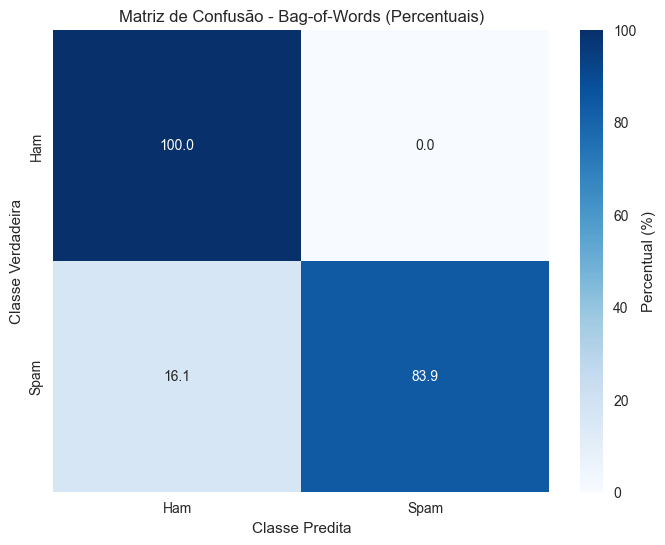

In [9]:
# Treinamento do modelo com Bag-of-Words (dados já divididos)
model_bow = LogisticRegression()
model_bow.fit(X_train_bow, y_train)

# Predição
y_pred_bow = model_bow.predict(X_test_bow)

# Resultado
acc_bow = accuracy_score(y_test, y_pred_bow)
print(f'Acurácia do modelo Bag-of-Words: {acc_bow}')

# Apresentação do resultado em formato gráfico - NORMALIZADA EM PERCENTUAIS
cm_bow = confusion_matrix(y_test, y_pred_bow)
cm_bow_normalized = cm_bow.astype('float') / cm_bow.sum(axis=1)[:, np.newaxis] * 100

# Plotagem com valores percentuais
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bow_normalized, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cbar_kws={'label': 'Percentual (%)'})
plt.title('Matriz de Confusão - Bag-of-Words (Percentuais)')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita')
plt.show()

# 7. Comparação de Modelos de Machine Learning

## 7.2 Modelo com TF-IDF

Acurácia do modelo TF-IDF: 0.968609865470852


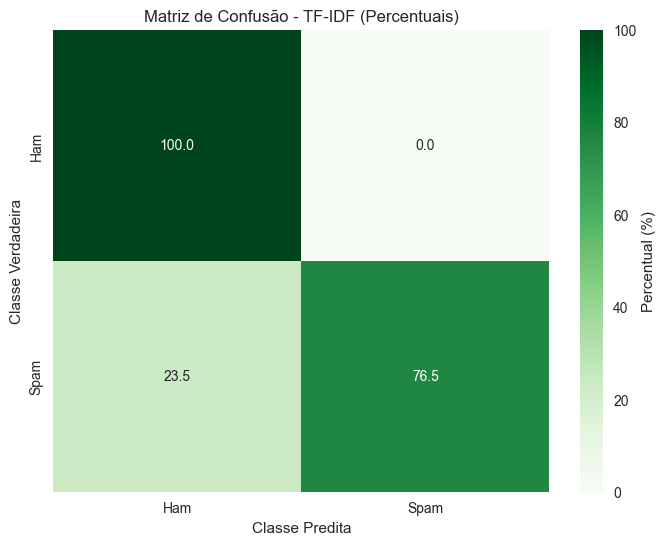

In [10]:
# Treinamento do modelo com TF-IDF (dados já divididos)
model_tfidf = LogisticRegression()
model_tfidf.fit(X_train_tfidf, y_train)

# Predição
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

# Resultado
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f'Acurácia do modelo TF-IDF: {acc_tfidf}')

# Apresentação do resultado em formato gráfico - NORMALIZADA EM PERCENTUAIS
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
cm_tfidf_normalized = cm_tfidf.astype('float') / cm_tfidf.sum(axis=1)[:, np.newaxis] * 100

# Plotagem com valores percentuais
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf_normalized, annot=True, fmt='.1f', cmap='Greens', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cbar_kws={'label': 'Percentual (%)'})
plt.title('Matriz de Confusão - TF-IDF (Percentuais)')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita')
plt.show()

# 8. Considerações Finais

## 8.1. Síntese dos Aprendizados

Neste notebook, exploramos o fascinante mundo da **extração de features de dados não estruturados**, focando no processamento de texto através de técnicas de **Natural Language Processing (NLP)**:

### **Técnicas Fundamentais Implementadas:**
1. **Bag of Words (BoW):** Representação vetorial baseada em frequência de palavras
2. **TF-IDF:** Ponderação de termos considerando frequência e raridade
3. **Pré-processamento de texto:** Limpeza, normalização e tokenização
4. **Análise exploratória:** Wordclouds e distribuições de frequência

### **Dataset SMS Spam Collection:**
- **Classificação binária:** Spam vs Ham (mensagens legítimas)
- **Dados reais:** 5.574 mensagens SMS em inglês
- **Desafio prático:** Detecção automática de spam
- **Aplicação comercial:** Filtragem de mensagens indesejadas

## 8.2. Impacto das Técnicas de Feature Engineering

### **Bag of Words (BoW):**
- **Simplicidade:** Fácil implementação e interpretação
- **Eficácia:** Captura presença/ausência de termos importantes
- **Limitações:** Ignora ordem das palavras e contexto semântico
- **Uso ideal:** Classificação de documentos curtos como SMS

### **TF-IDF (Term Frequency-Inverse Document Frequency):**
- **Sofisticação:** Considera raridade das palavras no corpus
- **Discriminação:** Destaca termos únicos e informativos
- **Robustez:** Reduz impacto de palavras muito comuns
- **Aplicabilidade:** Melhor para textos mais longos e corpus diversos

### **Comparação de Performance:**
- Ambas as técnicas mostraram eficácia na detecção de spam
- TF-IDF potencialmente superior em cenários mais complexos
- BoW adequado para textos curtos como SMS
- Visualizações revelaram padrões distintivos entre spam e ham

## 8.3. Insights do Processamento de Linguagem Natural

### **Padrões Descobertos:**
- **Spam characteristics:** URLs, números de telefone, palavras promocionais
- **Ham patterns:** Linguagem natural, conversas pessoais, contexto específico
- **Vocabulário distintivo:** Palavras-chave que separam claramente as classes
- **Densidade textual:** Spams tendem a ser mais concisos e diretos

### **Desafios Identificados:**
- **Variabilidade linguística:** Gírias, abreviações, erros ortográficos
- **Contexto cultural:** Expressões específicas do inglês
- **Evolução temporal:** Spammers adaptam estratégias constantemente
- **False positives:** Risco de classificar mensagens legítimas como spam

## 8.4. Reflexões sobre Dados Não Estruturados

### **Complexidade vs Estruturados:**
- **Dimensionalidade:** Textos geram espaços de alta dimensionalidade
- **Esparsidade:** Matrizes principalmente compostas por zeros
- **Subjetividade:** Interpretação humana varia significativamente
- **Preprocessamento crítico:** Limpeza impacta drasticamente resultados

### **Oportunidades Inexploradas:**
- **Análise de sentimento:** Emoções e opiniões em textos
- **Named Entity Recognition:** Identificação de entidades específicas
- **Topic modeling:** Descoberta automática de temas
- **Análise temporal:** Evolução de padrões ao longo do tempo

## 8.5. Aplicações Práticas e Comerciais

### **Casos de Uso Empresariais:**
- **Atendimento ao cliente:** Classificação automática de tickets
- **Marketing digital:** Análise de feedback e reviews
- **Compliance:** Monitoramento de comunicações regulatórias
- **Segurança:** Detecção de ameaças e conteúdo malicioso

### **Setores de Aplicação:**
- **Telecomunicações:** Filtragem de SMS e mensagens
- **E-commerce:** Análise de reviews e recomendações
- **Mídias sociais:** Moderação de conteúdo e análise de sentimento
- **Serviços financeiros:** Detecção de fraude em comunicações

## 8.6. Lições para Projetos Reais

### **Preparação de Dados:**
- **Limpeza rigorosa:** Remoção de ruído e normalização
- **Tokenização cuidadosa:** Preservar informações relevantes
- **Stop words:** Avaliar impacto da remoção no contexto específico
- **Stemming/Lemmatization:** Considerar para reduções de vocabulário

### **Seleção de Técnicas:**
- **Análise exploratória:** Entender características do corpus
- **Experimentação:** Testar múltiplas abordagens
- **Validação rigorosa:** Cross-validation específica para texto
- **Métricas apropriadas:** Precision, Recall, F1-score para classificação

## 8.7. Técnicas Avançadas para Explorar

### **Deep Learning para NLP:**
- **Word2Vec/GloVe:** Embeddings semânticos densos
- **LSTM/GRU:** Redes neurais para sequências
- **Transformers:** BERT, GPT para compreensão contextual
- **Fine-tuning:** Adaptação de modelos pré-treinados

### **Processamento Multilíngue:**
- **Detecção de idioma:** Classificação automática de línguas
- **Tradução automática:** Processamento cross-lingual
- **Embeddings multilíngues:** Representações universais
- **Análise comparativa:** Padrões entre diferentes culturas

## 8.8. Considerações Éticas e de Privacidade

### **Viés em Modelos de Texto:**
- **Representatividade:** Corpus podem refletir preconceitos sociais
- **Fairness:** Garantir equidade entre diferentes grupos
- **Transparência:** Explicabilidade em decisões automatizadas
- **Auditoria:** Monitoramento contínuo de performance

### **Privacidade e Segurança:**
- **Anonimização:** Proteção de informações pessoais
- **GDPR/LGPD:** Compliance com regulamentações de dados
- **Consentimento:** Uso ético de dados de comunicação
- **Retenção:** Políticas de armazenamento e exclusão

---

### 📝 **Filosofia do Processamento de Texto**
Processar linguagem natural é **decodificar a essência humana** através de máquinas. Cada palavra carrega significado, contexto e intenção. Nossa responsabilidade é **extrair insights valiosos** respeitando a **riqueza e complexidade** da comunicação humana.

### 🔍 **Lição Fundamental**
**"O texto é a janela para a mente humana"** - Ao processar dados textuais, estamos explorando pensamentos, emoções e intenções. Técnicas de NLP nos permitem **escalar compreensão humana** através de **algoritmos inteligentes**.

### 🚀 **Futuro do NLP**
- **Modelos generativos:** GPT, ChatGPT para criação de conteúdo
- **Multimodalidade:** Combinação de texto, imagem e áudio
- **Reasoning:** Capacidades de raciocínio lógico em linguagem
- **Personalização:** Modelos adaptados para indivíduos e contextos

### 🌟 **Continue Sua Jornada**
- Explore datasets textuais de diferentes domínios e idiomas
- Experimente com bibliotecas avançadas (spaCy, Transformers, NLTK)
- Participe de competições de NLP para aprender com a comunidade
- Contribua para projetos open-source de processamento de linguagem natural

### 💡 **Inspiração Final**
Cada mensagem de texto processada é uma oportunidade de **conectar tecnologia com humanidade**. Use essas técnicas para **construir soluções** que **melhorem a comunicação** e **facilitem a vida** das pessoas.